# Exercício 1

Um professor universitário ministrou aulas online em vez de aulas presenciais devido ao Covid-19. Posteriormente, ele carregou as aulas gravadas na nuvem para os alunos que seguiram o curso de forma assíncrona (aqueles que não assistiram à aula, mas assistiram às gravações posteriormente). No entanto, ele acredita que os alunos que assistem à aula no horário da aula e participam do processo são mais bem-sucedidos. Portanto, ele registrou as notas médias dos alunos no final do semestre. Os dados estão abaixo.

Conduza o teste de hipótese para verificar se a crença do professor é estatisticamente significativa, usando um nível de significância de 0,05 para avaliar as hipóteses nula e alternativa. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. 

In [2]:
import pandas as pd

DADOS_NOTAS_COVID = "../../dados/notas_covid.csv"

df_notas_covid = pd.read_csv(DADOS_NOTAS_COVID)

df_notas_covid

,sync,async
0,94.0,77.1
1,84.9,71.7
2,82.6,91.0
3,69.5,72.2
4,80.1,74.8
5,79.6,85.1
6,81.4,67.6
7,77.8,69.9
8,81.7,75.3
9,78.8,71.7


In [3]:
# 1. Comparando médias 
# 2. síncrono vs assíncrono → 2 grupos
# 3. Tipo de comparação: entre grupos independentes
# 4. Objetivo: verificar se um grupo tem média maior 

df_notas_covid.info()


<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sync    22 non-null     float64
 1   async   14 non-null     float64
dtypes: float64(2)
memory usage: 484.0 bytes


In [11]:
df_notas_covid.describe()

,sync,async
count,22.000000,14.000000
mean,81.013636,74.600000
std,6.533962,6.710726
min,69.500000,65.700000
25%,77.925000,71.550000
50%,80.350000,72.400000
75%,84.325000,76.650000
max,94.000000,91.000000


- A média do grupo síncrono (81,0) é maior que a do assíncrono (74,6).
- A dispersão (desvio padrão) é bem parecida entre os dois grupos (~6,5).
- O mínimo e máximo mostram faixas similares, mas o síncrono tende a valores mais altos.

A análise descritiva indica que os alunos que participaram das aulas de forma síncrona apresentaram média de desempenho superior (81,0) em comparação aos alunos assíncronos (74,6). A dispersão dos dados é semelhante entre os grupos, indicando variabilidade comparável.

<Axes: ylabel='Count'>

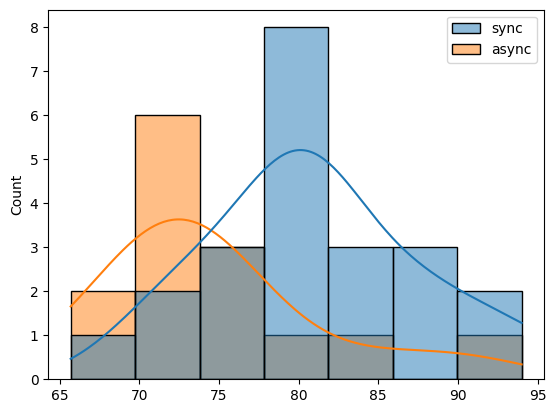

In [12]:
import seaborn as sns

sns.histplot(df_notas_covid, kde=True)

O histograma com estimativa de densidade (KDE) indica que as notas do grupo síncrono estão, em geral, deslocadas para valores mais altos em comparação ao grupo assíncrono. Observa-se também que as distribuições apresentam formatos aproximadamente simétricos, sugerindo possível normalidade, ainda que com alguma assimetria no grupo assíncrono.

<Axes: >

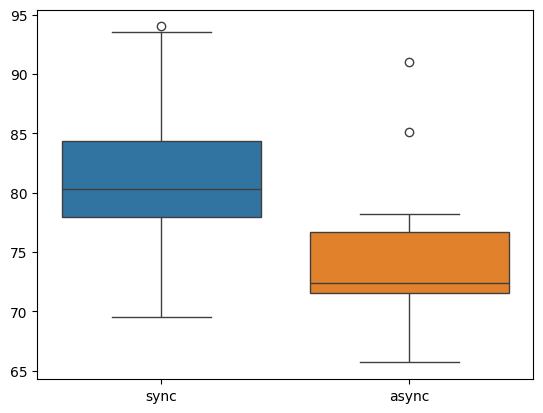

In [13]:
sns.boxplot(df_notas_covid)

O boxplot evidencia que o grupo síncrono apresenta mediana superior ao grupo assíncrono, sugerindo melhor desempenho médio. Observa-se ainda variabilidade semelhante entre os grupos e a presença de alguns valores discrepantes (outliers) em ambos os casos.

In [16]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_notas_covid)

Teste de Shapiro-Wilk
estatistica_sw=0.968
sync segue uma distribuição normal (valor p: 0.656)
estatistica_sw=0.890
async segue uma distribuição normal (valor p: 0.080)

Teste de Levene
estatistica_levene=0.008
Variâncias iguais (valor p: 0.931)


In [17]:
from auxiliares import analise_ttest_ind

analise_ttest_ind(df_notas_covid)

Teste t de Student
estatistica_ttest=2.841
Rejeita a hipótese nula (valor p: 0.008)


Após verificar as suposições de normalidade (Shapiro–Wilk) e homogeneidade de variâncias (Levene), foi aplicado o teste t para amostras independentes. O resultado indicou diferença estatisticamente significativa entre os grupos (t = 2,841; p = 0,008), ao nível de significância de 5%. Assim, rejeita-se a hipótese nula, indicando que os alunos que assistiram às aulas de forma síncrona apresentaram desempenho médio significativamente superior ao dos alunos que acompanharam as aulas de forma assíncrona.

Os resultados sugerem que a participação nas aulas ao vivo está associada a um melhor desempenho acadêmico, reforçando a percepção do professor sobre a importância da participação síncrona no processo de aprendizagem.

---------------------------------------------------------------------------------------------------------


# Exercício 2

Um pediatra quer ver o efeito do consumo de fórmula no ganho médio de peso mensal (em grama) de bebês. Por esse motivo, ela coletou dados de três grupos diferentes. O primeiro grupo é composto por crianças alimentadas exclusivamente com leite materno, o segundo grupo é composto por crianças alimentadas apenas com fórmula e o último grupo é composto por crianças alimentadas com fórmula e leite materno. Esses dados estão abaixo.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o ganho médio mensal desses três grupos usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [18]:
import pandas as pd

DADOS_LEITE_FORMULA = "../../dados/leite_formula_ambos.csv"

df_leite_formula = pd.read_csv(DADOS_LEITE_FORMULA)
df_leite_formula

,apenas_leite,apenas_formula,ambos
0,794.1,898.8,976.4
1,716.9,881.2,656.4
2,993.0,940.2,861.2
3,724.7,966.2,706.8
4,760.9,957.5,718.5
5,908.2,1061.7,717.1
6,659.3,1046.2,759.8
7,690.8,980.4,894.6
8,768.7,895.6,867.6
9,717.3,919.7,805.6


In [19]:
df_leite_formula.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   apenas_leite    17 non-null     float64
 1   apenas_formula  19 non-null     float64
 2   ambos           23 non-null     float64
dtypes: float64(3)
memory usage: 684.0 bytes


In [20]:
df_leite_formula.describe()

,apenas_leite,apenas_formula,ambos
count,17.000000,19.000000,23.000000
mean,749.823529,959.215789,809.952174
std,102.007062,89.159004,79.859546
min,583.500000,796.300000,656.400000
25%,690.800000,897.200000,762.600000
50%,724.700000,952.500000,799.400000
75%,794.100000,1021.550000,864.400000
max,993.000000,1160.500000,976.400000


<Axes: ylabel='Count'>

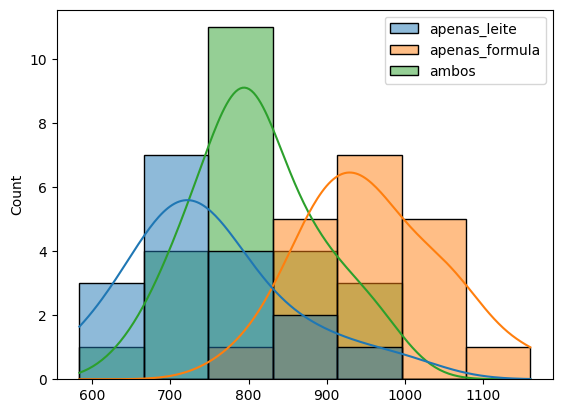

In [21]:
import seaborn as sns 

sns.histplot(df_leite_formula, kde=True)

<Axes: >

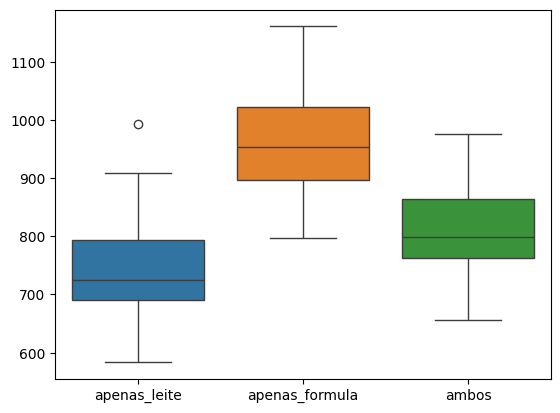

In [22]:
sns.boxplot(df_leite_formula)

In [24]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_leite_formula)

Teste de Shapiro-Wilk
estatistica_sw=0.951
apenas_leite segue uma distribuição normal (valor p: 0.469)
estatistica_sw=0.976
apenas_formula segue uma distribuição normal (valor p: 0.888)
estatistica_sw=0.975
ambos segue uma distribuição normal (valor p: 0.797)

Teste de Levene
estatistica_levene=0.389
Variâncias iguais (valor p: 0.680)


In [25]:
from auxiliares import analise_anova_one_way

analise_anova_one_way(df_leite_formula)

Teste ANOVA one way
estatistica_f=26.701
Rejeita a hipótese nula (valor p: 0.000)


# Exercício 3


Um especialista em recursos humanos que trabalha em uma empresa de tecnologia está interessado no tempo de trabalho excessivo de diferentes equipes. Para investigar se há diferença entre o tempo extra da equipe de desenvolvimento de software e da equipe de teste, ela selecionou 17 funcionários aleatoriamente em cada uma das duas equipes e registrou seu tempo médio de trabalho extra semanal em termos de hora. Os dados estão abaixo.


De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o tempo extra de trabalho das duas equipes usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [5]:
import pandas as pd

DADOS_TEMPOS_TIMES = "../../dados/tempos_times.csv"

df_tempos_times = pd.read_csv(DADOS_TEMPOS_TIMES)
df_tempos_times

,test_team,developer_team
0,6.2,2.3
1,7.1,2.1
2,1.5,1.4
3,2.0,2.0
4,3.0,8.7
5,2.0,2.2
6,1.5,3.1
7,6.1,4.2
8,2.4,3.6
9,2.3,2.5


# Exercício 4


Uma empresa de comércio eletrônico anuncia regularmente no YouTube, Instagram e Facebook para suas campanhas. No entanto, o novo gerente estava curioso para saber se havia alguma diferença entre o número de clientes atraídos por essas plataformas. Portanto, ela começou a usar o Adjust, um aplicativo que permite descobrir de onde vêm seus usuários. Os números diários relatados pelo Adjust para cada plataforma estão abaixo.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre a aquisição média de clientes dessas três plataformas usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas.

In [6]:
import pandas as pd

DADOS_ANUNCIOS = "../../dados/anuncios_redes_sociais.csv"

df_anuncios = pd.read_csv(DADOS_ANUNCIOS)
df_anuncios

,youtube,instagram,facebook
0,1913,2305,2133
1,1879,2355,2522
2,1939,2203,2124
3,2146,2231,2551
4,2040,2185,2293
5,2127,2420,2367
6,2122,2386,2460
7,2156,2410,2311
8,2036,2340,2178
9,1974,2349,2113


# Exercício 5

O Centro de Saúde de uma universidade diagnosticou dezoito estudantes com colesterol alto no semestre anterior. O pessoal de saúde informou a esses pacientes sobre os perigos do colesterol alto e prescreveu um programa de dieta. Um mês depois, os pacientes vieram para controle, e seu nível de colesterol foi reexaminado. Teste se há diferença nos níveis de colesterol dos pacientes.

De acordo com essas informações, conduza o teste de hipótese para verificar se há uma diminuição nos níveis de colesterol dos pacientes após a dieta, usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [7]:
import pandas as pd

DADOS_COLESTEROL = "../../dados/dieta_colesterol.csv"

df_colesterol = pd.read_csv(DADOS_COLESTEROL)
df_colesterol

,antes_dieta,depois_dieta
0,224,198
1,235,195
2,223,213
3,253,190
4,253,246
5,224,206
6,244,225
7,225,199
8,259,214
9,220,210


# Exercício 6


Uma gestora de um fundo de investimentos queria investir em uma startup que fornece compressão de dados sem perda de qualidade, mas existem dois concorrentes: PiedPiper e EndFrame. Inicialmente, ela acreditava que o desempenho do EndFrame poderia ser melhor, mas ainda queria testá-lo antes do investimento. Em seguida, ela deu os mesmos arquivos para cada empresa comprimir e registrou suas pontuações de desempenho. Os dados estão abaixo.

De acordo com essas informações, conduza o teste de hipótese relacionado usando um nível de significância de 0,05. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [8]:
import pandas as pd

DADOS_COMPRESSAO = "../../dados/tempos_compressao.csv"

df_tempos_compressao = pd.read_csv(DADOS_COMPRESSAO)
df_tempos_compressao

,piedpiper,endframe
0,4.57,4.27
1,4.55,3.93
2,5.47,4.01
3,4.67,4.07
4,5.41,3.87
5,5.55,4.00
6,5.53,4.00
7,5.63,3.72
8,3.86,4.16
9,3.97,4.10


# Exercício 7

Uma pesquisadora estava curiosa para saber se há diferença entre a metodologia que ela desenvolveu para detectar a concentração de uma droga em amostras de sangue, C, e os métodos de linha de base A e B em termos de desempenho. Portanto, ela decidiu projetar diferentes experimentos e registrou a precisão alcançada por cada método. A tabela abaixo mostra a precisão alcançada nos conjuntos de teste por cada método. Observe que os mesmos conjuntos de treinamento e teste foram usados para cada método.

De acordo com essas informações, conduza o teste de hipótese para verificar se há diferença entre o desempenho dos métodos usando um nível de significância de 0,05. Se houver diferença significativa, realize uma análise adicional para descobrir o que causou a diferença. Antes de fazer o teste de hipótese, verifique as suposições relacionadas. Comente sobre os resultados.

In [9]:
import pandas as pd

DADOS_METODOS = "../../dados/metodos_deteccao_sangue.csv"

df_metodos = pd.read_csv(DADOS_METODOS)
df_metodos

,metodo_A,metodo_B,metodo_C
0,89.8,90.0,91.5
1,89.9,90.1,90.7
2,88.6,88.8,90.3
3,88.7,88.9,90.4
4,89.6,89.9,90.2
5,89.7,90.0,90.3
6,89.2,89.0,90.2
7,89.3,89.2,90.3


# Exercício 8

Um analista de uma empresa de investimentos financeiros está curioso sobre a relação entre gênero e apetite por risco. Uma amostra aleatória foi retirada do banco de dados com 660 clientes. Os clientes da amostra foram classificados de acordo com seu gênero e seu apetite por risco. O resultado é dado na tabela a seguir.

Gênero/Risco |	Muito Baixo 	| Baixo |	Médio | 	Alto | 	Muito Alto | 	Total
--- | --- | --- | --- | --- | --- | ---
Feminino |  53 	| 23 | 30 |	36 |	88 |	230
Masculino 	| 71 	| 48 |	51 	| 57 	| 203 	| 430
Total 	| 124 	| 71 | 	81 |	93 |	291 |	660

Teste a hipótese de que o apetite por risco dos clientes nesta empresa é independente de seu gênero. Use **α = 0,01**.


In [10]:
import pandas as pd

DADOS_GENEROS_RISCO = "../../dados/risco_genero.csv"

df_risco = pd.read_csv(DADOS_GENEROS_RISCO, index_col=0)
df_risco

,muito_baixo,baixo,medio,alto,muito_alto
feminino,53,23,30,36,88
masculino,71,48,51,57,203
